<a href="https://colab.research.google.com/github/mienye/Projects-/blob/main/Teya_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:

from google.colab import drive
drive.mount('/content/drive')
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Loading dataset
df = pd.read_csv('/content/drive/My Drive/Datasets/new_transactions.csv', parse_dates=['transaction_create_date'])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-12-b7ffe1cefcb5>:10: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/My Drive/Datasets/new_transactions.csv', parse_dates=['transaction_create_date'])


In [13]:
df.head()

,merchant_id,terminal_id,transaction_create_date,transaction_id,transaction_total_amount,merchant_registration_date,has_loyalty,transaction_currency,transaction_tip_amount,transaction_account_type,country,Ranking
0,2,5544719,03/09/2020 14:28,685387,449.0,13/08/2020 22:31,NaN,GBP,0.0,NaN,GBR,1
1,2,5544719,03/09/2020 14:30,685662,570.0,13/08/2020 22:31,NaN,GBP,0.0,NaN,GBR,2
2,2,5544719,03/09/2020 14:50,690487,395.0,13/08/2020 22:31,NaN,GBP,0.0,NaN,GBR,3
3,2,5544719,03/09/2020 14:52,690987,395.0,13/08/2020 22:31,NaN,GBP,0.0,NaN,GBR,4
4,2,5544719,03/09/2020 15:02,692937,525.0,13/08/2020 22:31,NaN,GBP,0.0,NaN,GBR,5


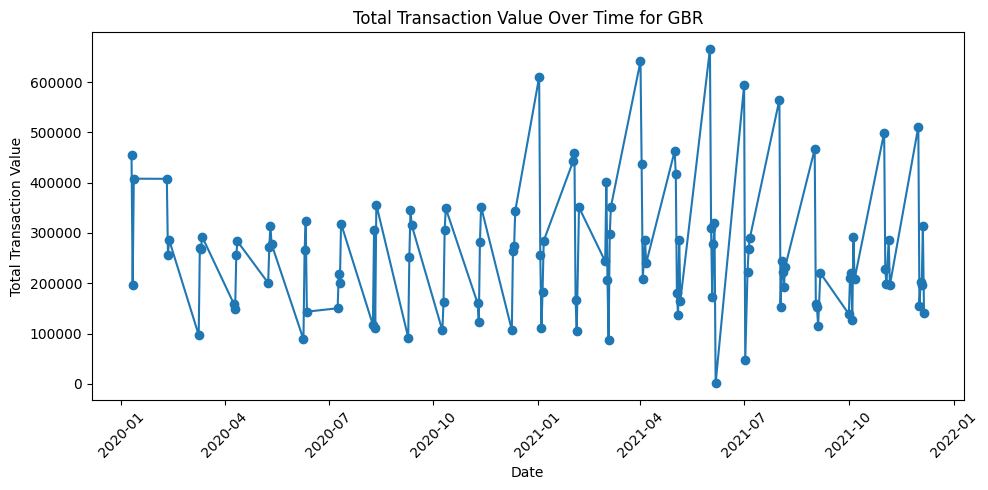

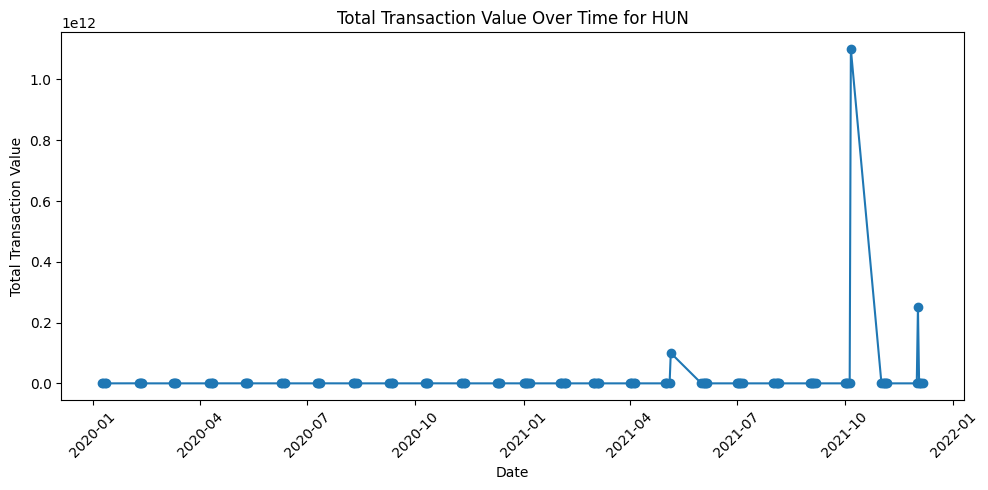

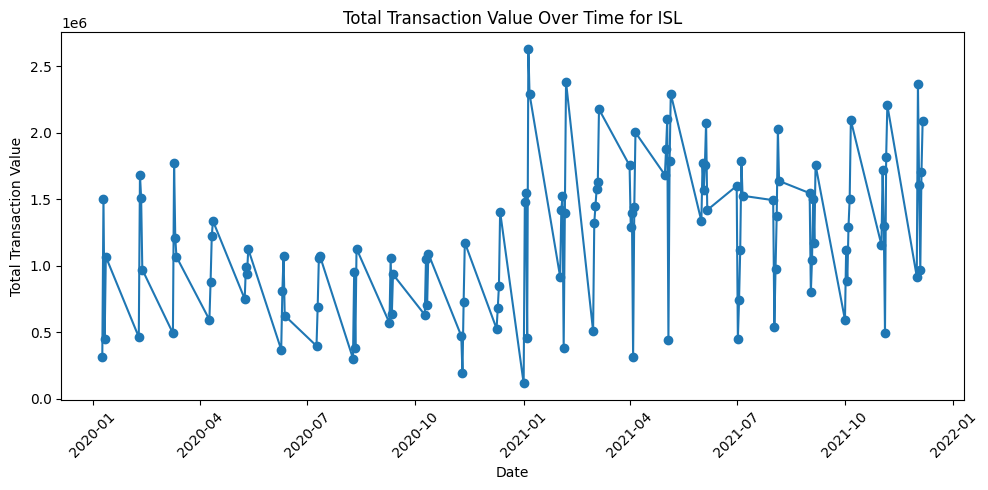

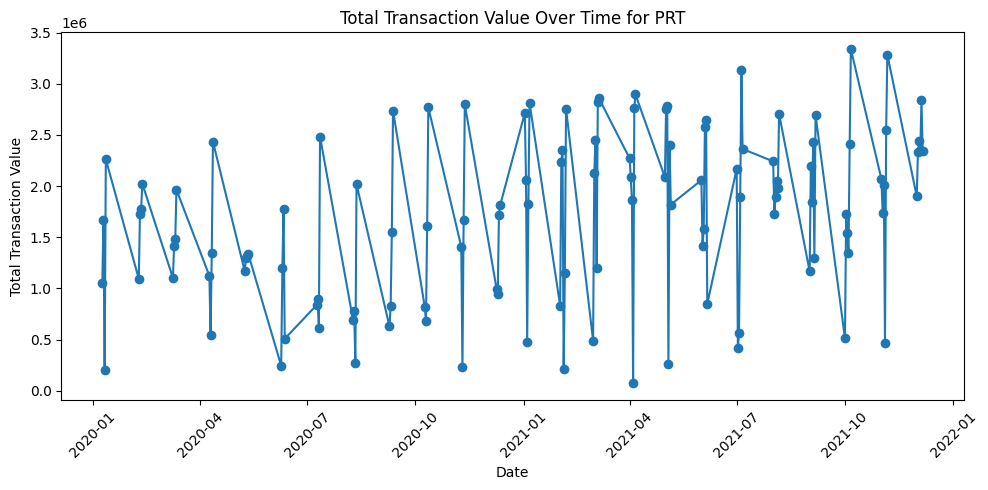

In [16]:

from statsmodels.tsa.seasonal import seasonal_decompose

df['transaction_create_date'] = pd.to_datetime(df['transaction_create_date'], errors='coerce')
df['merchant_registration_date'] = pd.to_datetime(df['merchant_registration_date'], errors='coerce')

df['transaction_total_amount'] = pd.to_numeric(df['transaction_total_amount'], errors='coerce')

# =============================
# Part (a): Plot TPV for each country over time
# =============================
# Creating a new column for just the date part
df['transaction_date'] = df['transaction_create_date'].dt.date

# Here I Group by country and transaction_date to sum the total transaction values
tpv_country = df.groupby(['country', 'transaction_date'])['transaction_total_amount'].sum().reset_index()

# For each country, I aim to plot the total transaction value over time
countries = tpv_country['country'].unique()
for country in countries:
    subset = tpv_country[tpv_country['country'] == country]
    plt.figure(figsize=(10, 5))
    plt.plot(pd.to_datetime(subset['transaction_date']), subset['transaction_total_amount'], marker='o', linestyle='-')
    plt.title(f"Total Transaction Value Over Time for {country}")
    plt.xlabel("Date")
    plt.ylabel("Total Transaction Value")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'tpv_{country}.png')
    plt.show()


In [17]:
# =============================
# Part (b): Add a country prefix to merchant_id and calculate TPV per country
# =============================
df['merchant_id_prefixed'] = df['country'] + '_' + df['merchant_id'].astype(str)

# Calculating the total TPV per country using the transaction_total_amount column
tpv_by_country = df.groupby('country')['transaction_total_amount'].sum().reset_index()

# Print and save the aggregated TPV per country to a CSV file
print("Total Transaction Value per Country:")
print(tpv_by_country)
tpv_by_country.to_csv('TPV_by_country.csv', index=False)



Total Transaction Value per Country:
  country  transaction_total_amount
0     GBR              7.153846e+07
1     HUN              1.651531e+12
2     ISL              3.450778e+08
3     PRT              5.042310e+08


<ipython-input-18-8b0b638fbc2d>:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = monthly.groupby(pd.Grouper(key='transaction_date', freq='M'))['transaction_total_amount'].sum().reset_index()


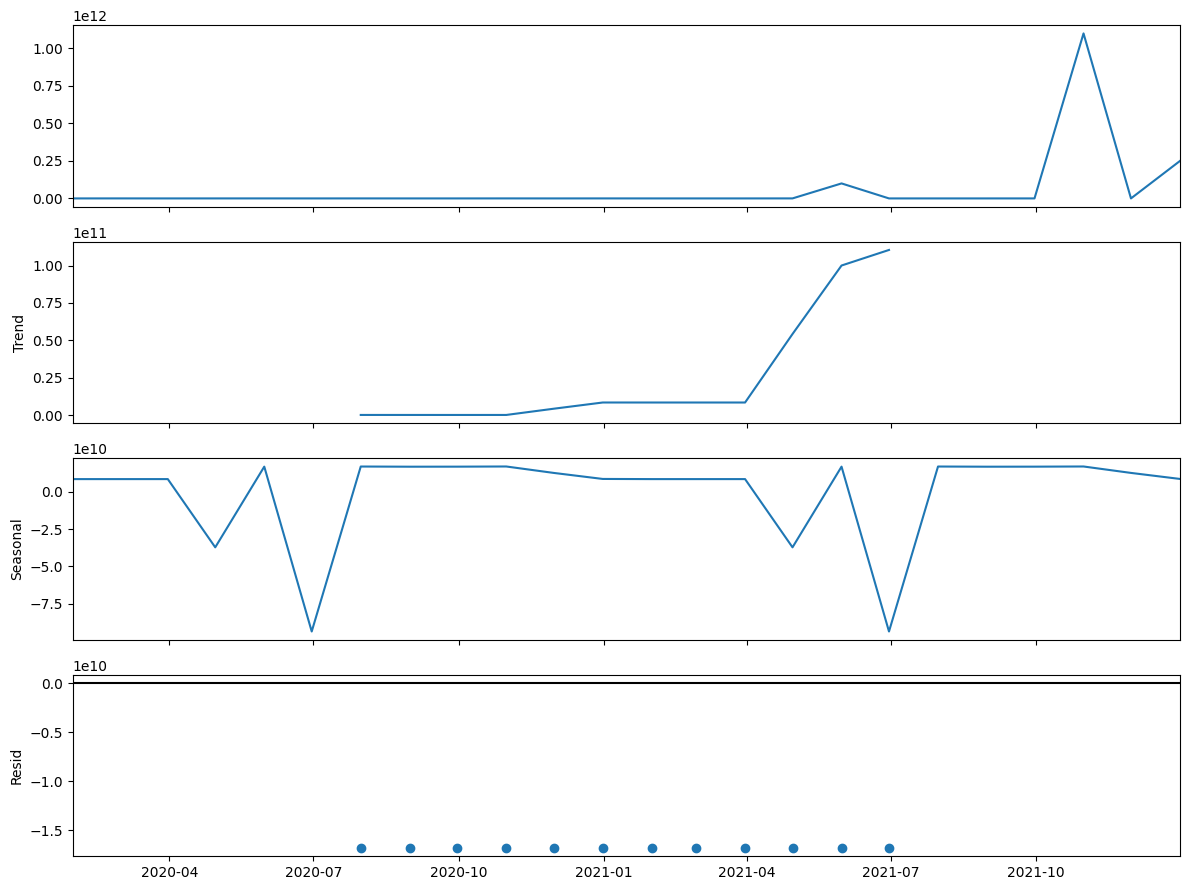

In [18]:
# =============================
# Part (c): Seasonality Analysis
# =============================
# For seasonality, I aggregate the TPV on a monthly basis.
monthly = df.copy()
# here I use the full timestamp from transaction_create_date for aggregation)
monthly['transaction_date'] = pd.to_datetime(monthly['transaction_create_date'])
monthly = monthly.groupby(pd.Grouper(key='transaction_date', freq='M'))['transaction_total_amount'].sum().reset_index()
monthly = monthly.set_index('transaction_date')

# Perform seasonal decomposition (assuming a yearly seasonality, period=12)
decomposition = seasonal_decompose(monthly, model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 9)
plt.tight_layout()
plt.savefig('seasonality_decomposition.png')
plt.show()
